In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import numpy.ma as ma
from domain import *
import xarray as xr
from netCDF4 import Dataset
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import calendar

In [2]:
dsMA=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')
dsHMA = field_dom(dsMA,'HMA')
dsSH_hma=dsHMA['elevation']
LONS_hma,LATS_hma=dsHMA.longitude,dsHMA.latitude

In [3]:
# Tien Shan
dsCH = field_dom(dsHMA, 'Tien Shan')
dsSH_CH = dsCH['elevation']
LONS_CH, LATS_CH = dsCH.longitude, dsCH.latitude

# Hindu-Kush
dsHKU = field_dom(dsHMA, 'Hundu-Kush')
dsSH_HKU = dsHKU['elevation']
LONS_HKU, LATS_HKU = dsHKU.longitude, dsHKU.latitude

# Pamir
dsPAM = field_dom(dsHMA, 'Pamir')
dsSH_PAM = dsPAM['elevation']
LONS_PAM, LATS_PAM = dsPAM.longitude, dsPAM.latitude

# Spiti-Lahul
dsSL = field_dom(dsHMA, 'Spiti-Lahul')
dsSH_SL = dsSL['elevation']
LONS_SL, LATS_SL = dsSL.longitude, dsSL.latitude

# Karakoram
dsKAR = field_dom(dsHMA, 'Karakoram')
dsSH_KAR = dsKAR['elevation']
LONS_KAR, LATS_KAR = dsKAR.longitude, dsKAR.latitude

# West-Nepal
dsWNE = field_dom(dsHMA, 'West-Nepal')
dsSH_WNE = dsWNE['elevation']
LONS_WNE, LATS_WNE = dsWNE.longitude, dsWNE.latitude

# Bhutan
dsBHU = field_dom(dsHMA, 'Bhutan')
dsSH_BHU = dsBHU['elevation']
LONS_BHU, LATS_BHU = dsBHU.longitude, dsBHU.latitude

# Everest
dsEVE = field_dom(dsHMA, 'Everest')
dsSH_EVE = dsEVE['elevation']
LONS_EVE, LATS_EVE = dsEVE.longitude, dsEVE.latitude

# Nayainqentangla
dsNAY = field_dom(dsHMA, 'Nayainqentangla')
dsSH_NAY = dsNAY['elevation']
LONS_NAY, LATS_NAY = dsNAY.longitude, dsNAY.latitude

# Pamir-Altai
dsPAL = field_dom(dsHMA, 'Pamir-Altai')
dsSH_PAL = dsPAL['elevation']
LONS_PAL, LATS_PAL = dsPAL.longitude, dsPAL.latitude

# Kunlun
dsKUN = field_dom(dsHMA, 'Kunlun')
dsSH_KUN = dsKUN['elevation']
LONS_KUN, LATS_KUN = dsKUN.longitude, dsKUN.latitude

# TP2
dsTP2 = field_dom(dsHMA, 'TP2')
dsSH_TP2 = dsTP2['elevation']
LONS_TP2, LATS_TP2 = dsTP2.longitude, dsTP2.latitude

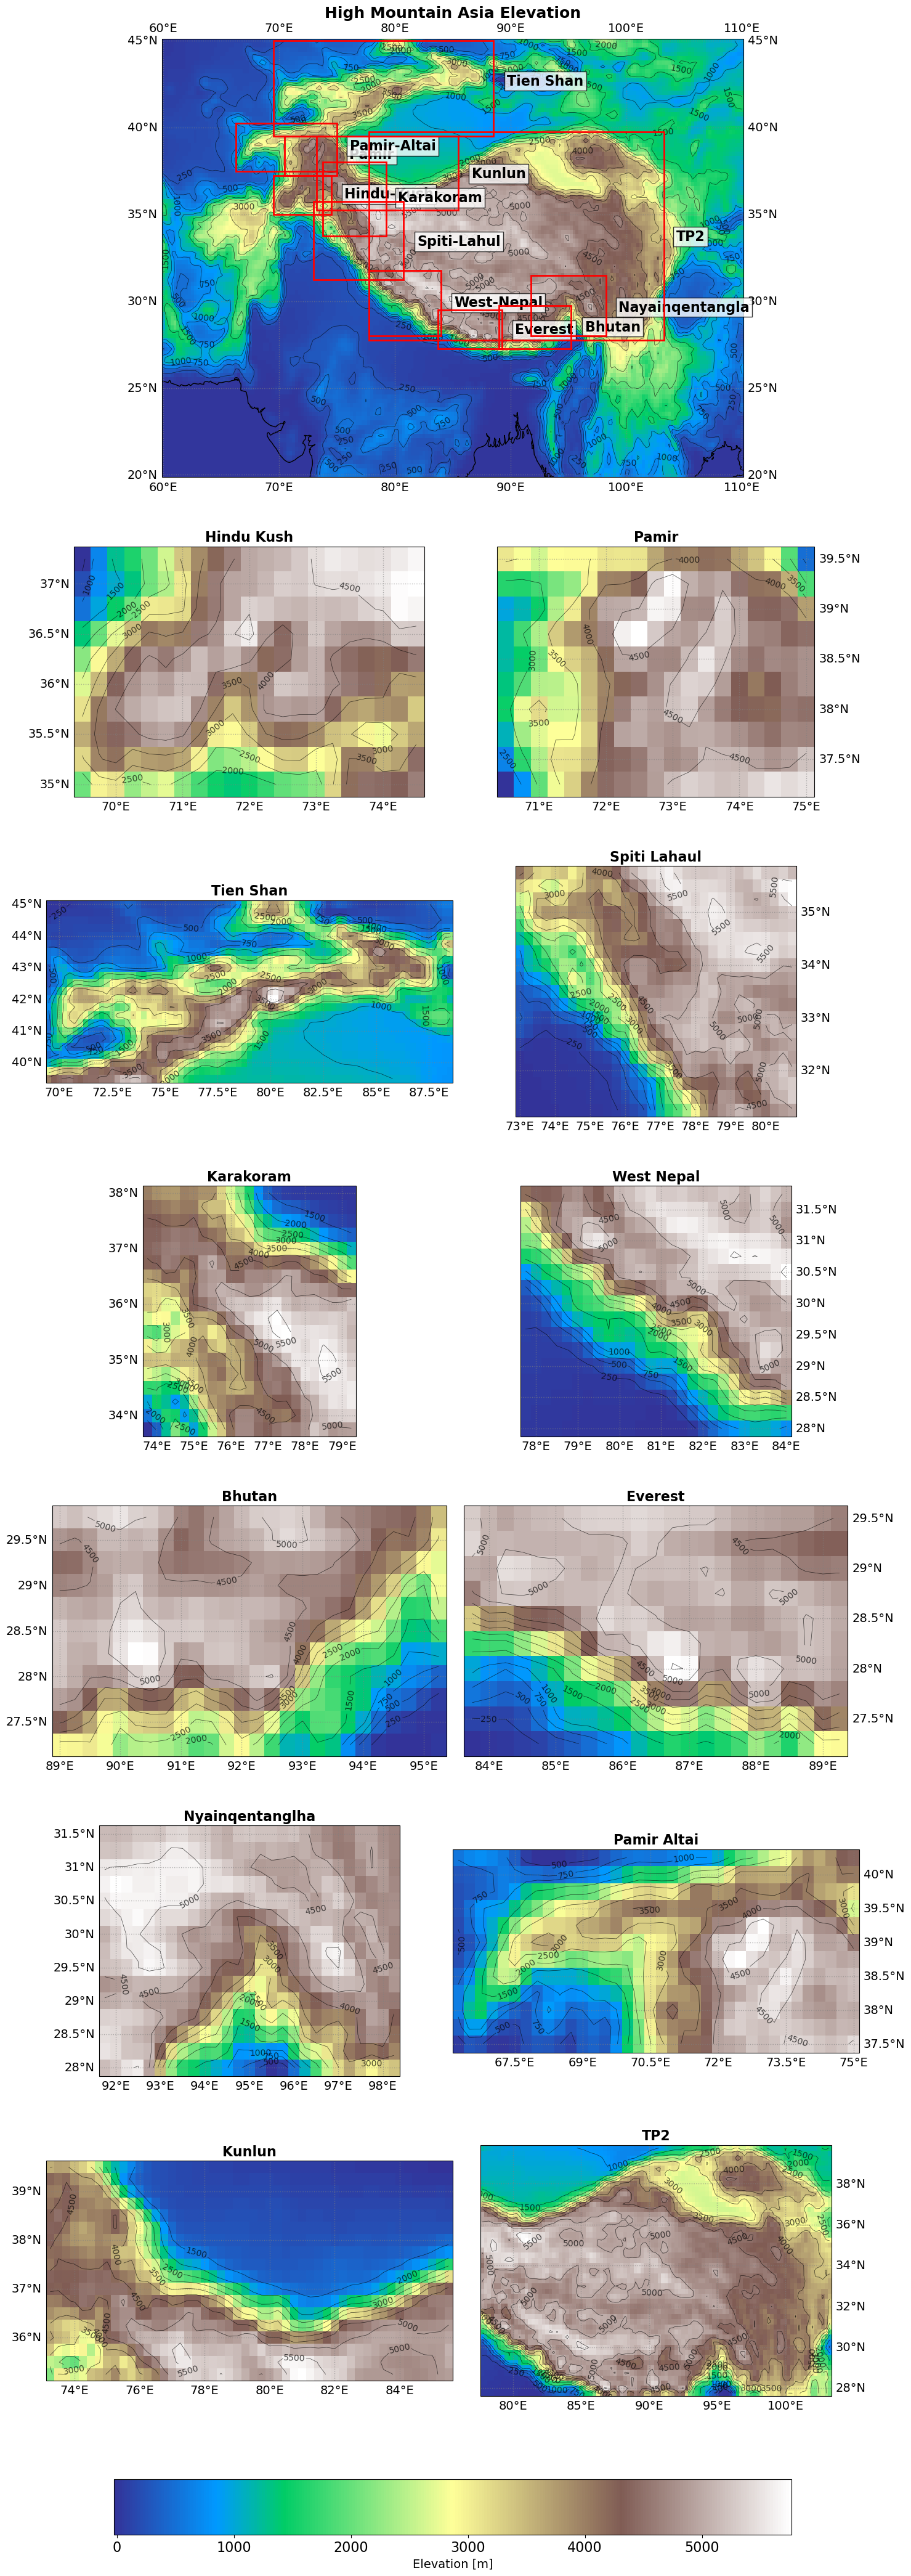

In [13]:
cmap='terrain'

# Compute rectangle coordinates automatically
# Tien Shan
CH_box = [LONS_CH.min().item(), LONS_CH.max().item(), LATS_CH.min().item(), LATS_CH.max().item()]

# Hindu-Kush
HKU_box = [LONS_HKU.min().item(), LONS_HKU.max().item(), LATS_HKU.min().item(), LATS_HKU.max().item()]

# Pamir
PAM_box = [LONS_PAM.min().item(), LONS_PAM.max().item(), LATS_PAM.min().item(), LATS_PAM.max().item()]

# Spiti-Lahul
SL_box = [LONS_SL.min().item(), LONS_SL.max().item(), LATS_SL.min().item(), LATS_SL.max().item()]

# Karakoram
KAR_box = [LONS_KAR.min().item(), LONS_KAR.max().item(), LATS_KAR.min().item(), LATS_KAR.max().item()]

# West-Nepal
WNE_box = [LONS_WNE.min().item(), LONS_WNE.max().item(), LATS_WNE.min().item(), LATS_WNE.max().item()]

# Bhutan
BHU_box = [LONS_BHU.min().item(), LONS_BHU.max().item(), LATS_BHU.min().item(), LATS_BHU.max().item()]

# Everest
EVE_box = [LONS_EVE.min().item(), LONS_EVE.max().item(), LATS_EVE.min().item(), LATS_EVE.max().item()]

# Nayainqentangla
NAY_box = [LONS_NAY.min().item(), LONS_NAY.max().item(), LATS_NAY.min().item(), LATS_NAY.max().item()]

# Pamir-Altai
PAL_box = [LONS_PAL.min().item(), LONS_PAL.max().item(), LATS_PAL.min().item(), LATS_PAL.max().item()]

# Kunlun
KUN_box = [LONS_KUN.min().item(), LONS_KUN.max().item(), LATS_KUN.min().item(), LATS_KUN.max().item()]

# TP2
TP2_box = [LONS_TP2.min().item(), LONS_TP2.max().item(), LATS_TP2.min().item(), LATS_TP2.max().item()]


# Create figure and gridspec layout
# Taille 65 pour accommoder les 7 rangées sans écraser les proportions
fig = plt.figure(figsize=(22, 45))
gs = fig.add_gridspec(7, 2, height_ratios=[1.75, 1, 1, 1, 1, 1, 1])

# Row 1: full-width HMA plot
ax0 = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
CS0 = ax0.pcolormesh(LONS_hma, LATS_hma, dsSH_hma,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap, shading="auto")
ax0.coastlines()
ax0.set_title('High Mountain Asia Elevation', fontsize=18, weight="bold")
gl0 = ax0.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                   linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl0.xlabel_style = {"size": 14}
gl0.ylabel_style = {"size": 14}
ax0.set_aspect(1.5)
SH0 = ax0.contour(LONS_hma, LATS_hma, dsSH_hma,
                  levels=[250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
                  colors="k", linewidths=0.5, alpha=0.7,
                  transform=ccrs.PlateCarree())
ax0.clabel(SH0, inline=True, fontsize=10, fmt="%d")

# Add red rectangles for subdomains
all_boxes = [CH_box, HKU_box, PAM_box, SL_box, KAR_box, WNE_box, BHU_box, EVE_box, NAY_box, PAL_box, KUN_box, TP2_box]
for box in all_boxes:
    rect = Rectangle((box[0], box[2]), box[1]-box[0], box[3]-box[2],
                     linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree(), zorder=10)
    ax0.add_patch(rect)

#Add text zone pour les 12 subregions (placé à droite du box)

# 1. Tien Shan
latS, latN, lonW, lonE = coord_domain('Tien Shan')
ax0.text(lonE + 1, (latS + latN) / 2, "Tien Shan", horizontalalignment='left', verticalalignment='center', 
         fontsize=16, fontweight='bold', color='black', transform=ccrs.PlateCarree(), zorder=7, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# 2. Hindu-Kush
latS, latN, lonW, lonE = coord_domain('Hundu-Kush')
ax0.text(lonE + 1, (latS + latN) / 2, "Hindu-Kush", horizontalalignment='left', verticalalignment='center', 
         fontsize=16, fontweight='bold', color='black', transform=ccrs.PlateCarree(), zorder=7, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# 3. Pamir
latS, latN, lonW, lonE = coord_domain('Pamir')
ax0.text(lonE + 1, (latS + latN) / 2, "Pamir", horizontalalignment='left', verticalalignment='center', 
         fontsize=16, fontweight='bold', color='black', transform=ccrs.PlateCarree(), zorder=7, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# 4. Spiti-Lahul
latS, latN, lonW, lonE = coord_domain('Spiti-Lahul')
ax0.text(lonE + 1, (latS + latN) / 2, "Spiti-Lahul", horizontalalignment='left', verticalalignment='center', 
         fontsize=16, fontweight='bold', color='black', transform=ccrs.PlateCarree(), zorder=7, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# 5. Karakoram
latS, latN, lonW, lonE = coord_domain('Karakoram')
ax0.text(lonE + 1, (latS + latN) / 2, "Karakoram", horizontalalignment='left', verticalalignment='center', 
         fontsize=16, fontweight='bold', color='black', transform=ccrs.PlateCarree(), zorder=7, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# 6. West-Nepal
latS, latN, lonW, lonE = coord_domain('West-Nepal')
ax0.text(lonE + 1, (latS + latN) / 2, "West-Nepal", horizontalalignment='left', verticalalignment='center', 
         fontsize=16, fontweight='bold', color='black', transform=ccrs.PlateCarree(), zorder=7, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# 7. Bhutan
latS, latN, lonW, lonE = coord_domain('Bhutan')
ax0.text(lonE + 1, (latS + latN) / 2, "Bhutan", horizontalalignment='left', verticalalignment='center', 
         fontsize=16, fontweight='bold', color='black', transform=ccrs.PlateCarree(), zorder=7, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# 8. Everest
latS, latN, lonW, lonE = coord_domain('Everest')
ax0.text(lonE + 1, (latS + latN) / 2, "Everest", horizontalalignment='left', verticalalignment='center', 
         fontsize=16, fontweight='bold', color='black', transform=ccrs.PlateCarree(), zorder=7, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# 9. Nayainqentangla
latS, latN, lonW, lonE = coord_domain('Nayainqentangla')
ax0.text(lonE + 1, (latS + latN) / 2, "Nayainqentangla", horizontalalignment='left', verticalalignment='center', 
         fontsize=16, fontweight='bold', color='black', transform=ccrs.PlateCarree(), zorder=7, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# 10. Pamir-Altai
latS, latN, lonW, lonE = coord_domain('Pamir-Altai')
ax0.text(lonE + 1, (latS + latN) / 2, "Pamir-Altai", horizontalalignment='left', verticalalignment='center', 
         fontsize=16, fontweight='bold', color='black', transform=ccrs.PlateCarree(), zorder=7, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# 11. Kunlun
latS, latN, lonW, lonE = coord_domain('Kunlun')
ax0.text(lonE + 1, (latS + latN) / 2, "Kunlun", horizontalalignment='left', verticalalignment='center', 
         fontsize=16, fontweight='bold', color='black', transform=ccrs.PlateCarree(), zorder=7, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# 12. TP2
latS, latN, lonW, lonE = coord_domain('TP2')
ax0.text(lonE + 1, (latS + latN) / 2, "TP2", horizontalalignment='left', verticalalignment='center', 
         fontsize=16, fontweight='bold', color='black', transform=ccrs.PlateCarree(), zorder=7, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# Row 2: Hindu Kush & Pamir
ax1 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
ax1.pcolormesh(LONS_HKU, LATS_HKU, dsSH_HKU, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax1.set_title('Hindu Kush', fontsize=16, weight="bold")
gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl1.xlabel_style = {"size": 14}; gl1.ylabel_style = {"size": 14}
gl1.top_labels = False; gl1.right_labels = False
ax1.set_aspect(1.5)
SH1 = ax1.contour(LONS_HKU, LATS_HKU, dsSH_HKU,
                  levels=[250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
                  colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
ax1.clabel(SH1, inline=True, fontsize=10, fmt="%d")

ax2 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
ax2.pcolormesh(LONS_PAM, LATS_PAM, dsSH_PAM, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax2.set_title('Pamir', fontsize=16, weight="bold")
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl2.xlabel_style = {"size": 14}; gl2.ylabel_style = {"size": 14}
gl2.top_labels = False; gl2.left_labels = False
ax2.set_aspect(1.5)
SH2 = ax2.contour(LONS_PAM, LATS_PAM, dsSH_PAM,
                  levels=[250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
                  colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
ax2.clabel(SH2, inline=True, fontsize=10, fmt="%d")

# Row 3: Tien Shan & Spiti Lahaul
ax3 = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree())
ax3.pcolormesh(LONS_CH, LATS_CH, dsSH_CH, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax3.set_title('Tien Shan', fontsize=16, weight="bold")
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl3.xlabel_style = {"size": 14}; gl3.ylabel_style = {"size": 14}
gl3.top_labels = False; gl3.right_labels = False
ax3.set_aspect(1.5)
SH3 = ax3.contour(LONS_CH, LATS_CH, dsSH_CH,
                  levels=[250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
                  colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
ax3.clabel(SH3, inline=True, fontsize=10, fmt="%d")

ax4 = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree())
ax4.pcolormesh(LONS_SL, LATS_SL, dsSH_SL, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax4.set_title('Spiti Lahaul', fontsize=16, weight="bold")
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl4.xlabel_style = {"size": 14}; gl4.ylabel_style = {"size": 14}
gl4.top_labels = False; gl4.left_labels = False
ax4.set_aspect(1.5)
SH4 = ax4.contour(LONS_SL, LATS_SL, dsSH_SL,
                  levels=[250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
                  colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
ax4.clabel(SH4, inline=True, fontsize=10, fmt="%d")

# Row 4: Karakoram & West Nepal
ax5 = fig.add_subplot(gs[3, 0], projection=ccrs.PlateCarree())
ax5.pcolormesh(LONS_KAR, LATS_KAR, dsSH_KAR, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax5.set_title('Karakoram', fontsize=16, weight="bold")
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl5.xlabel_style = {"size": 14}; gl5.ylabel_style = {"size": 14}
gl5.top_labels = False; gl5.right_labels = False
ax5.set_aspect(1.5)
SH5 = ax5.contour(LONS_KAR, LATS_KAR, dsSH_KAR,
                  levels=[250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
                  colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
ax5.clabel(SH5, inline=True, fontsize=10, fmt="%d")

ax6 = fig.add_subplot(gs[3, 1], projection=ccrs.PlateCarree())
ax6.pcolormesh(LONS_WNE, LATS_WNE, dsSH_WNE, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax6.set_title('West Nepal', fontsize=16, weight="bold")
gl6 = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl6.xlabel_style = {"size": 14}; gl6.ylabel_style = {"size": 14}
gl6.top_labels = False; gl6.left_labels = False
ax6.set_aspect(1.5)
SH6 = ax6.contour(LONS_WNE, LATS_WNE, dsSH_WNE,
                  levels=[250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
                  colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
ax6.clabel(SH6, inline=True, fontsize=10, fmt="%d")

# Row 5: Bhutan & Everest
ax7 = fig.add_subplot(gs[4, 0], projection=ccrs.PlateCarree())
ax7.pcolormesh(LONS_BHU, LATS_BHU, dsSH_BHU, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax7.set_title('Bhutan', fontsize=16, weight="bold")
gl7 = ax7.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl7.xlabel_style = {"size": 14}; gl7.ylabel_style = {"size": 14}
gl7.top_labels = False; gl7.right_labels = False
ax7.set_aspect(1.5)
SH7 = ax7.contour(LONS_BHU, LATS_BHU, dsSH_BHU,
                  levels=[250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
                  colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
ax7.clabel(SH7, inline=True, fontsize=10, fmt="%d")

ax8 = fig.add_subplot(gs[4, 1], projection=ccrs.PlateCarree())
ax8.pcolormesh(LONS_EVE, LATS_EVE, dsSH_EVE, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax8.set_title('Everest', fontsize=16, weight="bold")
gl8 = ax8.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl8.xlabel_style = {"size": 14}; gl8.ylabel_style = {"size": 14}
gl8.top_labels = False; gl8.left_labels = False
ax8.set_aspect(1.5)
SH8 = ax8.contour(LONS_EVE, LATS_EVE, dsSH_EVE,
                  levels=[250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
                  colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
ax8.clabel(SH8, inline=True, fontsize=10, fmt="%d")

# Row 6: Nyainqentanglha & Pamir Altai
ax9 = fig.add_subplot(gs[5, 0], projection=ccrs.PlateCarree())
ax9.pcolormesh(LONS_NAY, LATS_NAY, dsSH_NAY, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax9.set_title('Nyainqentanglha', fontsize=16, weight="bold")
gl9 = ax9.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl9.xlabel_style = {"size": 14}; gl9.ylabel_style = {"size": 14}
gl9.top_labels = False; gl9.right_labels = False
ax9.set_aspect(1.5)
SH9 = ax9.contour(LONS_NAY, LATS_NAY, dsSH_NAY,
                  levels=[250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
                  colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
ax9.clabel(SH9, inline=True, fontsize=10, fmt="%d")

ax10 = fig.add_subplot(gs[5, 1], projection=ccrs.PlateCarree())
ax10.pcolormesh(LONS_PAL, LATS_PAL, dsSH_PAL, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax10.set_title('Pamir Altai', fontsize=16, weight="bold")
gl10 = ax10.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl10.xlabel_style = {"size": 14}; gl10.ylabel_style = {"size": 14}
gl10.top_labels = False; gl10.left_labels = False
ax10.set_aspect(1.5)
SH10 = ax10.contour(LONS_PAL, LATS_PAL, dsSH_PAL,
                  levels=[250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
                  colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
ax10.clabel(SH10, inline=True, fontsize=10, fmt="%d")

# Row 7: Kunlun & Tibetan Plateau 2
ax11 = fig.add_subplot(gs[6, 0], projection=ccrs.PlateCarree())
ax11.pcolormesh(LONS_KUN, LATS_KUN, dsSH_KUN, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax11.set_title('Kunlun', fontsize=16, weight="bold")
gl11 = ax11.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl11.xlabel_style = {"size": 14}; gl11.ylabel_style = {"size": 14}
gl11.top_labels = False; gl11.right_labels = False
ax11.set_aspect(1.5)
SH11 = ax11.contour(LONS_KUN, LATS_KUN, dsSH_KUN,
                  levels=[250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
                  colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
ax11.clabel(SH11, inline=True, fontsize=10, fmt="%d")

ax12 = fig.add_subplot(gs[6, 1], projection=ccrs.PlateCarree())
ax12.pcolormesh(LONS_TP2, LATS_TP2, dsSH_TP2, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax12.set_title('TP2', fontsize=16, weight="bold")
gl12 = ax12.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl12.xlabel_style = {"size": 14}; gl12.ylabel_style = {"size": 14}
gl12.top_labels = False; gl12.left_labels = False
ax12.set_aspect(1.5)
SH12 = ax12.contour(LONS_TP2, LATS_TP2, dsSH_TP2,
                  levels=[250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
                  colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
ax12.clabel(SH12, inline=True, fontsize=10, fmt="%d")

# Colorbar and layout adjustment
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])
cbar = fig.colorbar(CS0, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Elevation [m]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.00000001, hspace=0.25)

plt.show()

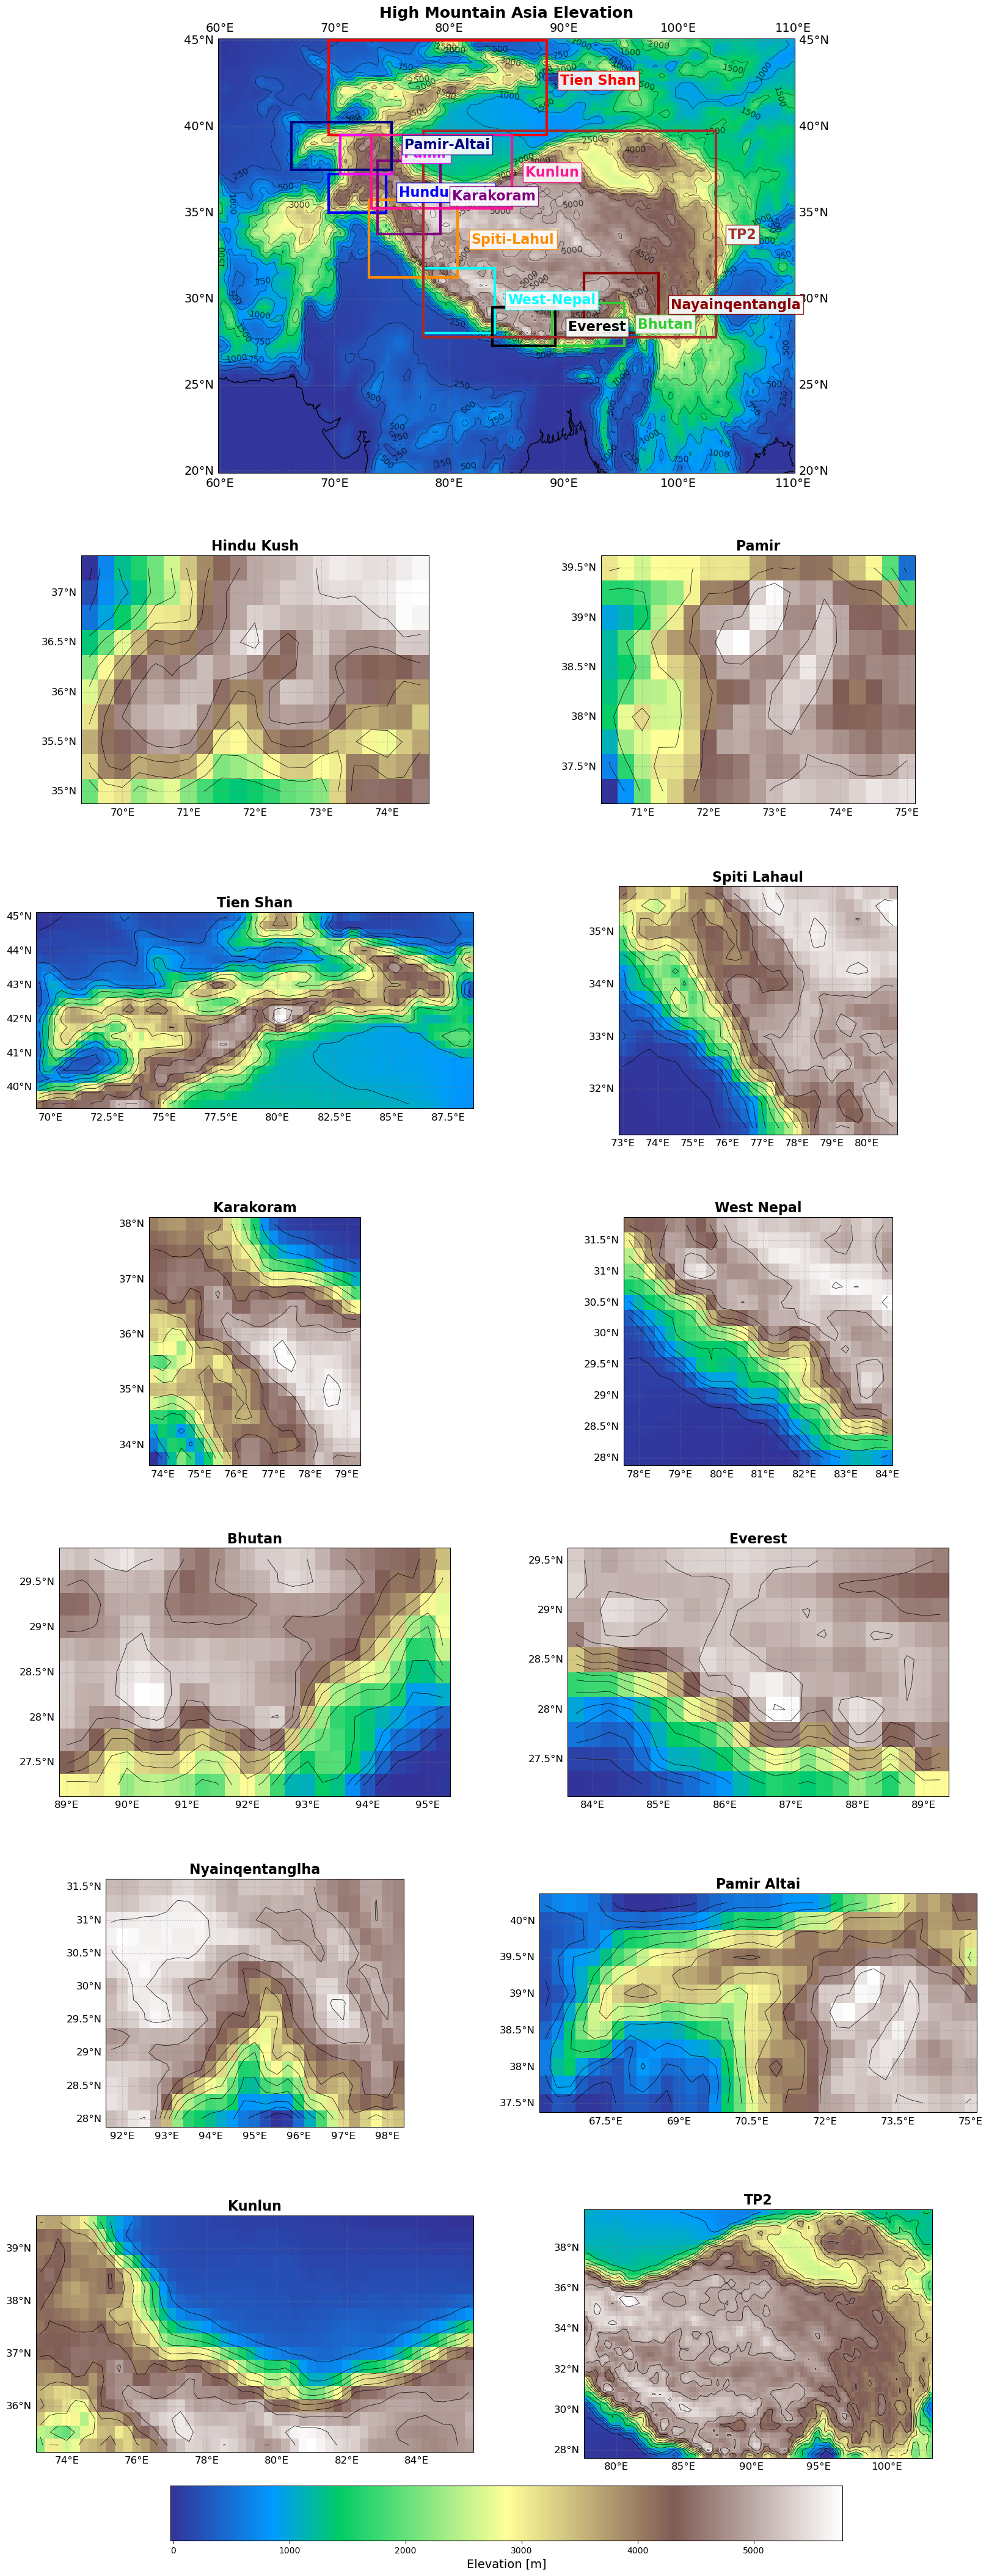

In [16]:
cmap = 'terrain'

# Liste de couleurs pour varier l'affichage des boîtes
# On utilise des couleurs vives qui tranchent bien sur le fond 'terrain'
colors_list = ['red', 'blue', 'magenta', 'darkorange', 'purple', 'cyan', 
               'limegreen', 'black', 'darkred', 'navy', 'deeppink', 'brown']

# Coordonnées des boîtes (calculées sur tes variables existantes)
all_boxes = [CH_box, HKU_box, PAM_box, SL_box, KAR_box, WNE_box, 
             BHU_box, EVE_box, NAY_box, PAL_box, KUN_box, TP2_box]

# Liste des noms pour coord_domain et l'affichage
region_names = ['Tien Shan', 'Hundu-Kush', 'Pamir', 'Spiti-Lahul', 'Karakoram', 
                'West-Nepal', 'Bhutan', 'Everest', 'Nayainqentangla', 
                'Pamir-Altai', 'Kunlun', 'TP2']

# Create figure and gridspec layout
fig = plt.figure(figsize=(22, 45))
gs = fig.add_gridspec(7, 2, height_ratios=[1.75, 1, 1, 1, 1, 1, 1])

# Row 1: full-width HMA plot
ax0 = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
CS0 = ax0.pcolormesh(LONS_hma, LATS_hma, dsSH_hma, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax0.coastlines()
ax0.set_title('High Mountain Asia Elevation', fontsize=18, weight="bold")
gl0 = ax0.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl0.xlabel_style = {"size": 14}; gl0.ylabel_style = {"size": 14}
ax0.set_aspect(1.5)

# Contours de niveau
lvls = [250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]
SH0 = ax0.contour(LONS_hma, LATS_hma, dsSH_hma, levels=lvls, colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
ax0.clabel(SH0, inline=True, fontsize=10, fmt="%d")

# --- AJOUT DES RECTANGLES ET TEXTES AVEC COULEURS DIFFÉRENTES ---
# On boucle sur les listes pour appliquer une couleur spécifique à chaque région
for i, box in enumerate(all_boxes):
    current_color = colors_list[i]
    current_name = region_names[i]
    
    # Dessin du rectangle sur ax0
    rect = Rectangle((box[0], box[2]), box[1]-box[0], box[3]-box[2],
                     linewidth=3, edgecolor=current_color, facecolor='none', 
                     transform=ccrs.PlateCarree(), zorder=10)
    ax0.add_patch(rect)
    
    # Récupération des coordonnées pour le texte via ta fonction
    latS, latN, lonW, lonE = coord_domain(current_name)
    
    # Ajout du texte à droite du box correspondant
    ax0.text(lonE + 1, (latS + latN) / 2, current_name, 
             horizontalalignment='left', verticalalignment='center', 
             fontsize=16, fontweight='bold', color=current_color, # Texte de la même couleur que le box
             transform=ccrs.PlateCarree(), zorder=11, 
             bbox=dict(facecolor='white', alpha=0.9, edgecolor=current_color, pad=3))

# --- BLOCS DES SOUS-FIGURES (Rangées 2 à 7) ---
# Hindu Kush & Pamir
ax1 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
ax1.pcolormesh(LONS_HKU, LATS_HKU, dsSH_HKU, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax1.set_title('Hindu Kush', fontsize=16, weight="bold", color=colors_list[7])
ax1.set_aspect(1.5)
ax1.contour(LONS_HKU, LATS_HKU, dsSH_HKU, levels=lvls, colors="k", linewidths=0.5, transform=ccrs.PlateCarree())

ax2 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
ax2.pcolormesh(LONS_PAM, LATS_PAM, dsSH_PAM, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax2.set_title('Pamir', fontsize=16, weight="bold", color=colors_list[7])
ax2.set_aspect(1.5)
ax2.contour(LONS_PAM, LATS_PAM, dsSH_PAM, levels=lvls, colors="k", linewidths=0.5, transform=ccrs.PlateCarree())

# Tien Shan & Spiti Lahaul
ax3 = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree())
ax3.pcolormesh(LONS_CH, LATS_CH, dsSH_CH, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax3.set_title('Tien Shan', fontsize=16, weight="bold", color=colors_list[7])
ax3.set_aspect(1.5)
ax3.contour(LONS_CH, LATS_CH, dsSH_CH, levels=lvls, colors="k", linewidths=0.5, transform=ccrs.PlateCarree())

ax4 = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree())
ax4.pcolormesh(LONS_SL, LATS_SL, dsSH_SL, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax4.set_title('Spiti Lahaul', fontsize=16, weight="bold", color=colors_list[7])
ax4.set_aspect(1.5)
ax4.contour(LONS_SL, LATS_SL, dsSH_SL, levels=lvls, colors="k", linewidths=0.5, transform=ccrs.PlateCarree())

# Karakoram & West Nepal
ax5 = fig.add_subplot(gs[3, 0], projection=ccrs.PlateCarree())
ax5.pcolormesh(LONS_KAR, LATS_KAR, dsSH_KAR, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax5.set_title('Karakoram', fontsize=16, weight="bold", color=colors_list[7])
ax5.set_aspect(1.5)
ax5.contour(LONS_KAR, LATS_KAR, dsSH_KAR, levels=lvls, colors="k", linewidths=0.5, transform=ccrs.PlateCarree())

ax6 = fig.add_subplot(gs[3, 1], projection=ccrs.PlateCarree())
ax6.pcolormesh(LONS_WNE, LATS_WNE, dsSH_WNE, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax6.set_title('West Nepal', fontsize=16, weight="bold", color=colors_list[7])
ax6.set_aspect(1.5)
ax6.contour(LONS_WNE, LATS_WNE, dsSH_WNE, levels=lvls, colors="k", linewidths=0.5, transform=ccrs.PlateCarree())

# Bhutan & Everest
ax7 = fig.add_subplot(gs[4, 0], projection=ccrs.PlateCarree())
ax7.pcolormesh(LONS_BHU, LATS_BHU, dsSH_BHU, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax7.set_title('Bhutan', fontsize=16, weight="bold", color=colors_list[7])
ax7.set_aspect(1.5)
ax7.contour(LONS_BHU, LATS_BHU, dsSH_BHU, levels=lvls, colors="k", linewidths=0.5, transform=ccrs.PlateCarree())

ax8 = fig.add_subplot(gs[4, 1], projection=ccrs.PlateCarree())
ax8.pcolormesh(LONS_EVE, LATS_EVE, dsSH_EVE, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax8.set_title('Everest', fontsize=16, weight="bold", color=colors_list[7])
ax8.set_aspect(1.5)
ax8.contour(LONS_EVE, LATS_EVE, dsSH_EVE, levels=lvls, colors="k", linewidths=0.5, transform=ccrs.PlateCarree())

# Nyainqentanglha & Pamir Altai
ax9 = fig.add_subplot(gs[5, 0], projection=ccrs.PlateCarree())
ax9.pcolormesh(LONS_NAY, LATS_NAY, dsSH_NAY, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax9.set_title('Nyainqentanglha', fontsize=16, weight="bold", color=colors_list[7])
ax9.set_aspect(1.5)
ax9.contour(LONS_NAY, LATS_NAY, dsSH_NAY, levels=lvls, colors="k", linewidths=0.5, transform=ccrs.PlateCarree())

ax10 = fig.add_subplot(gs[5, 1], projection=ccrs.PlateCarree())
ax10.pcolormesh(LONS_PAL, LATS_PAL, dsSH_PAL, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax10.set_title('Pamir Altai', fontsize=16, weight="bold", color=colors_list[7])
ax10.set_aspect(1.5)
ax10.contour(LONS_PAL, LATS_PAL, dsSH_PAL, levels=lvls, colors="k", linewidths=0.5, transform=ccrs.PlateCarree())

# Kunlun & TP2
ax11 = fig.add_subplot(gs[6, 0], projection=ccrs.PlateCarree())
ax11.pcolormesh(LONS_KUN, LATS_KUN, dsSH_KUN, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax11.set_title('Kunlun', fontsize=16, weight="bold", color=colors_list[7])
ax11.set_aspect(1.5)
ax11.contour(LONS_KUN, LATS_KUN, dsSH_KUN, levels=lvls, colors="k", linewidths=0.5, transform=ccrs.PlateCarree())

ax12 = fig.add_subplot(gs[6, 1], projection=ccrs.PlateCarree())
ax12.pcolormesh(LONS_TP2, LATS_TP2, dsSH_TP2, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
ax12.set_title('TP2', fontsize=16, weight="bold", color=colors_list[7])
ax12.set_aspect(1.5)
ax12.contour(LONS_TP2, LATS_TP2, dsSH_TP2, levels=lvls, colors="k", linewidths=0.5, transform=ccrs.PlateCarree())

# Réglage des gridlines pour tous les subplots (évite la répétition de code manuel)
for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12]:
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color="gray", alpha=0.5, linestyle=":")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

# Colorbar finale
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])
cbar = fig.colorbar(CS0, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Elevation [m]", fontsize=14)

fig.subplots_adjust(left=0.15, right=0.85, top=0.96, bottom=0.08, wspace=0.15, hspace=0.3)
plt.show()